In [2]:
from google.colab import files
uploaded=files.upload()


Saving Daily_Cal_Req.csv to Daily_Cal_Req (1).csv


In [3]:
import pandas as pd
df=pd.read_csv('Daily_Cal_Req.csv')
print(df.head())

    Age  Gender  Height_cm  Weight_kg Activity_Level  Sleep_Hours  \
0  58.0    Male      151.0       80.0          Light          5.6   
1  46.0  Female      150.0       65.0         Active          6.2   
2  53.0  Female      190.0       91.0    Very Active          5.5   
3  60.0  Female      154.0       66.0    Very Active          8.1   
4  35.0    Male      163.0       85.0          Light          7.8   

   Water_Intake_L      Goal Diet_Type  Daily_Calorie_Requirement  
0             3.6      Gain       Veg                       2306  
1             1.5  Maintain       Veg                       2064  
2             1.2      Gain   Non-Veg                       3476  
3             1.6      Gain     Vegan                       2207  
4             2.4      Gain      Jain                       2636  


In [4]:
df.isnull().sum()

,0
Age,25
Gender,25
Height_cm,0
Weight_kg,0
Activity_Level,0
Sleep_Hours,0
Water_Intake_L,0
Goal,0
Diet_Type,0
Daily_Calorie_Requirement,0


In [5]:
!pip install missingno

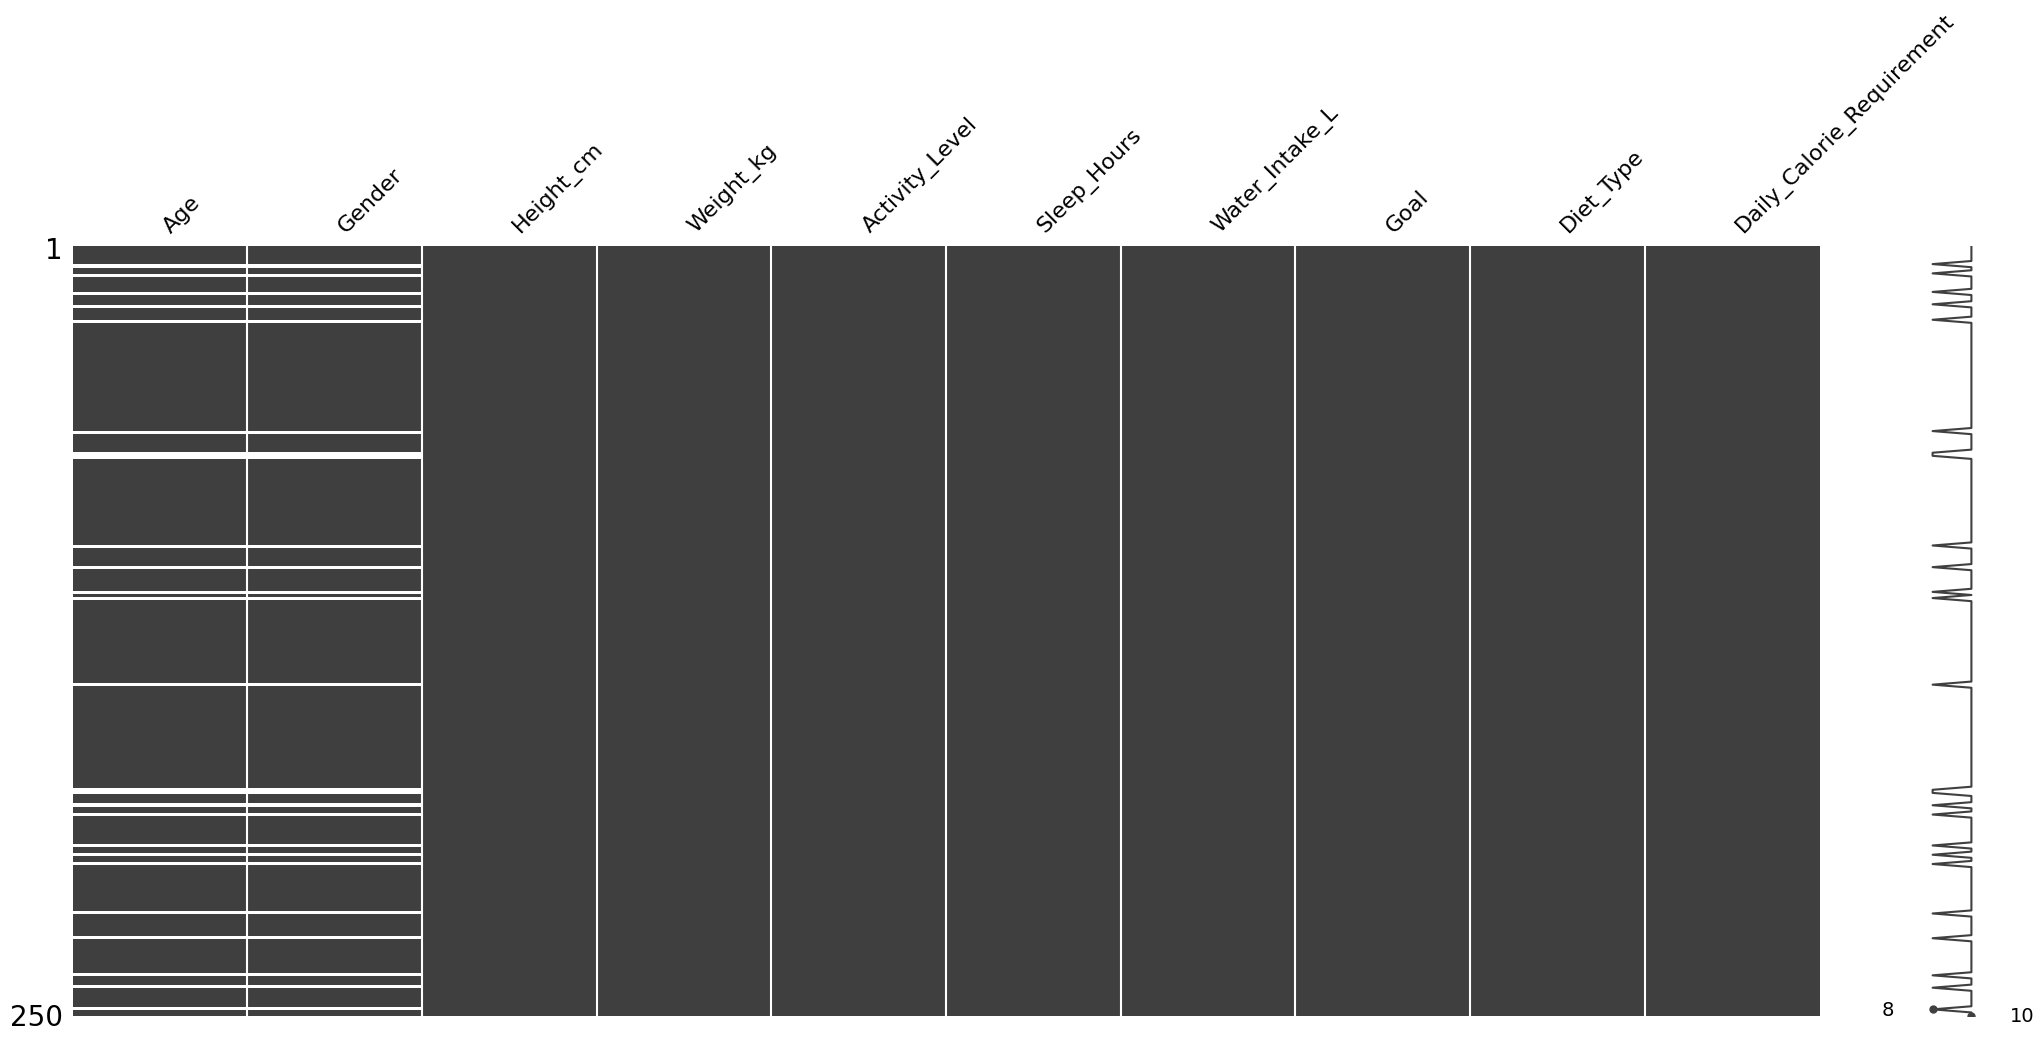

In [6]:
import matplotlib.pyplot as plt
import missingno as msno
msno.matrix(df)
plt.show()

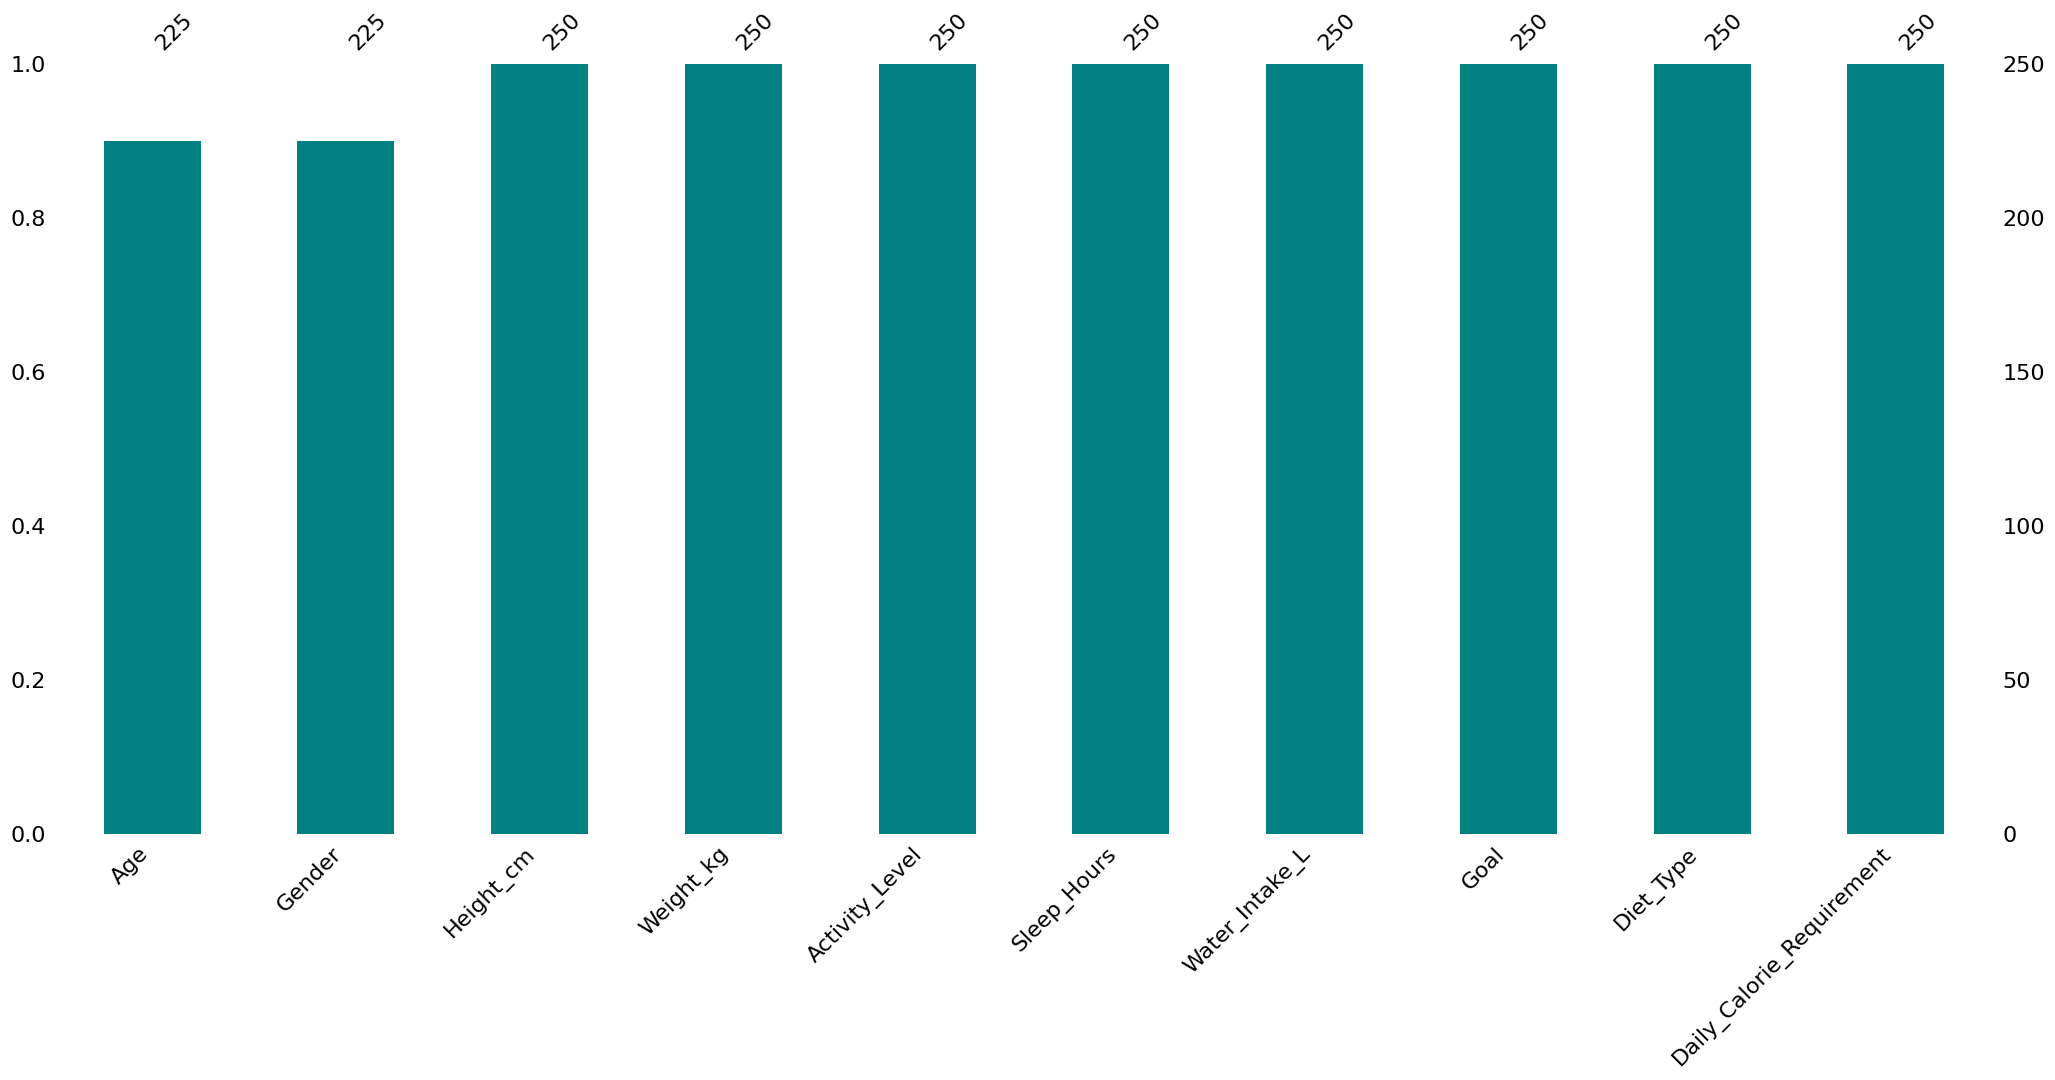

In [7]:
import matplotlib.pyplot as plt
msno.bar(df,color='teal')
plt.show()

In [8]:
df_new=df.dropna(axis=1)
df_new.shape

(250, 8)

In [9]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Activity_Level',
       'Sleep_Hours', 'Water_Intake_L', 'Goal', 'Diet_Type',
       'Daily_Calorie_Requirement'],
      dtype='object')

In [10]:
df.fillna({'Age':18,'Gender':'Male'},inplace=True)
df.isna().sum()

,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
Activity_Level,0
Sleep_Hours,0
Water_Intake_L,0
Goal,0
Diet_Type,0
Daily_Calorie_Requirement,0


In [11]:
df=pd.read_csv('Daily_Cal_Req.csv')
df.isna().sum()

,0
Age,25
Gender,25
Height_cm,0
Weight_kg,0
Activity_Level,0
Sleep_Hours,0
Water_Intake_L,0
Goal,0
Diet_Type,0
Daily_Calorie_Requirement,0


In [12]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Age'].isnull().sum()

np.int64(0)

In [13]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Gender'].isnull().sum().sum()

np.int64(0)

In [14]:
df['Gender'].mode()

,Gender
0,Male


In [15]:
df['Age'].median()

40.0

In [16]:
df.describe()

,Age,Height_cm,Weight_kg,Sleep_Hours,Water_Intake_L,Daily_Calorie_Requirement
count,250.000000,250.00000,250.000000,250.000000,250.000000,250.00000
mean,40.060000,170.50800,78.168000,7.158000,2.775200,2462.46000
std,11.388027,11.44438,18.307606,1.424272,0.965564,553.84209
min,18.000000,150.00000,45.000000,4.500000,1.000000,1167.00000
25%,32.250000,161.00000,64.000000,6.000000,2.000000,2088.50000
50%,40.000000,171.00000,81.000000,7.200000,2.700000,2404.00000
75%,49.000000,180.00000,91.000000,8.475000,3.600000,2823.50000
max,60.000000,190.00000,110.000000,9.500000,4.500000,4107.00000


In [17]:
import seaborn as sns


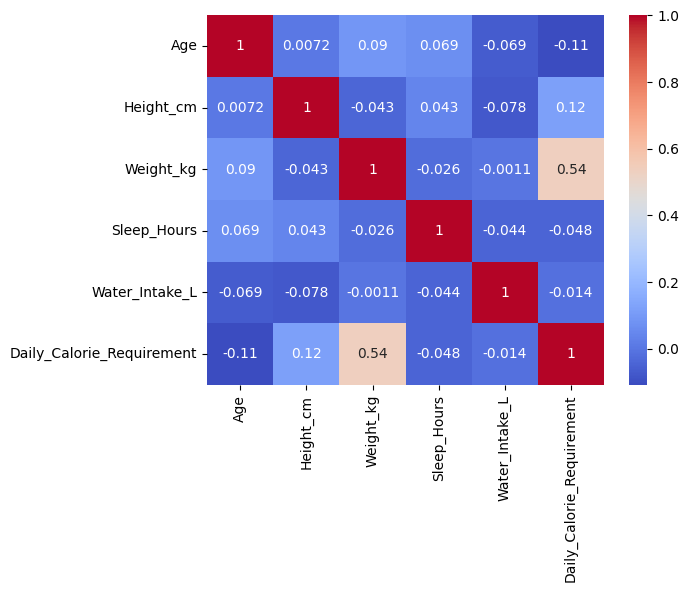

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [19]:
import plotly.express as px

In [20]:
fig=px.histogram(df,x='Age',nbins=10,color='Gender')
fig.update_layout(
    bargap=0.02,
    width=500,
    height=500)
fig.show()

In [21]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Activity_Level',
       'Sleep_Hours', 'Water_Intake_L', 'Goal', 'Diet_Type',
       'Daily_Calorie_Requirement'],
      dtype='object')

In [22]:
fig=px.scatter(
    df,
    x='Height_cm',
    y='Weight_kg',
    size='Daily_Calorie_Requirement',
    color='Activity_Level',
    hover_data='Age'
)
fig.show()

In [23]:
fig=px.treemap(
df,
path=['Goal','Activity_Level','Diet_Type']
)
fig.update_traces(
    textinfo='label+value'
)
fig.show()

In [24]:
fig = px.box(df, x='Goal', y='Daily_Calorie_Requirement', color='Goal', title='Daily Calorie Requirement by Goal')
fig.show()

In [25]:
from google.colab import files
uploaded=files.upload()

Saving employee_salary_regression.csv to employee_salary_regression.csv


In [26]:
import pandas as pd
df=pd.read_csv('employee_salary_regression.csv')
print(df.head())

  employee_id  age  years_experience education_level           job_role  \
0     EMP0001   29                 9          Master  Software Engineer   
1     EMP0002   27                 6        Bachelor        ML Engineer   
2     EMP0003   36                13          Master       Data Analyst   
3     EMP0004   43                23     High School             DevOps   
4     EMP0005   24                 1     High School             DevOps   

   city_tier  performance_score  num_skills  remote_work  annual_salary_usd  
0          1                2.4           3            0          106343.31  
1          3                2.1           5            1           82852.60  
2          1                4.1           7            1          142019.59  
3          1                3.1           7            1          159972.80  
4          1                3.7          12            1           94126.86  


In [27]:
df.describe()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.668000,18.617000,2.046000,3.506200,7.161000,0.488000,137295.111970
std,11.536415,11.634848,0.826176,0.863775,3.103661,0.500106,34692.969621
min,22.000000,0.000000,1.000000,2.000000,2.000000,0.000000,66716.640000
25%,30.000000,8.000000,1.000000,2.800000,4.000000,0.000000,107616.092500
50%,41.000000,19.000000,2.000000,3.500000,7.000000,0.000000,137537.955000
75%,51.000000,29.000000,3.000000,4.300000,10.000000,1.000000,164807.105000
max,60.000000,40.000000,3.000000,5.000000,12.000000,1.000000,217067.540000


In [28]:
df.columns

Index(['employee_id', 'age', 'years_experience', 'education_level', 'job_role',
       'city_tier', 'performance_score', 'num_skills', 'remote_work',
       'annual_salary_usd'],
      dtype='object')

In [29]:
df.select_dtypes(include='object').columns

Index(['employee_id', 'education_level', 'job_role'], dtype='object')

In [30]:
df.isnull().sum()

,0
employee_id,0
age,0
years_experience,0
education_level,0
job_role,0
city_tier,0
performance_score,0
num_skills,0
remote_work,0
annual_salary_usd,0


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
for col in ['education_level','job_role','city_tier']:
  print("_________________")
  print(df[col].value_counts())
print()



_________________
education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64
_________________
job_role
DevOps               190
Data Analyst         178
Product Manager      168
QA Engineer          165
Software Engineer    152
ML Engineer          147
Name: count, dtype: int64
_________________
city_tier
3    365
1    319
2    316
Name: count, dtype: int64



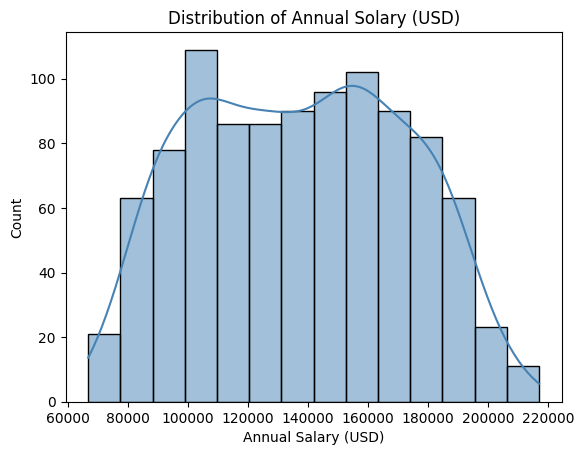

In [33]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.histplot(df['annual_salary_usd'], kde=True, color='steelblue')

plt.title('Distribution of Annual Solary (USD)')

plt.xlabel('Annual Salary (USD)')

plt.show()

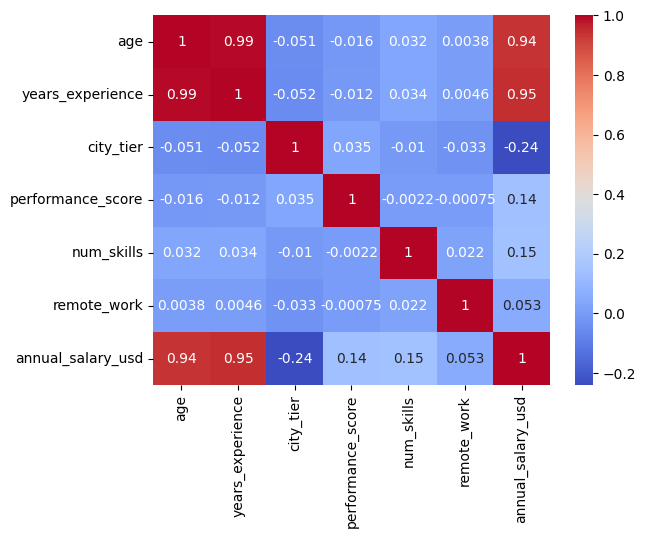

In [34]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()
# The NameError in the previous cell (EDwzuaZovvZj) occurred because 'X_train' and 'X_test' were used instead of 'x_train' and 'x_test' in the print statements.

In [35]:
df_encoded=pd.get_dummies(
    df.drop(columns='employee_id'),
    columns=['education_level','job_role'],
    drop_first=True

)
df_encoded.head()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,education_level_High School,education_level_Master,education_level_PhD,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
0,29,9,1,2.4,3,0,106343.31,False,True,False,False,False,False,False,True
1,27,6,3,2.1,5,1,82852.60,False,False,False,False,True,False,False,False
2,36,13,1,4.1,7,1,142019.59,False,True,False,False,False,False,False,False
3,43,23,1,3.1,7,1,159972.80,True,False,False,True,False,False,False,False
4,24,1,1,3.7,12,1,94126.86,True,False,False,True,False,False,False,False


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [37]:
x=df_encoded.drop(columns='annual_salary_usd')
y=df_encoded['annual_salary_usd']

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Training set size:",x_train.shape)
print("Testing set size:",x_test.shape)

Training set size: (800, 14)
Testing set size: (200, 14)


In [38]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

y_train_pred=lr_model.predict(x_train)
y_test_pred=lr_model.predict(x_test)

print("Model trained successfully.")

Model trained successfully.


In [40]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

test_rmse=root_mean_squared_error(y_test,y_test_pred)
test_r2=r2_score(y_test,y_test_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

print("R^2",round(test_r2,4))
print("MAE:",round(test_mae,2))
print("RMSE:",round(test_rmse,2))

R^2 0.9854
MAE: 3524.83
RMSE: 4381.87


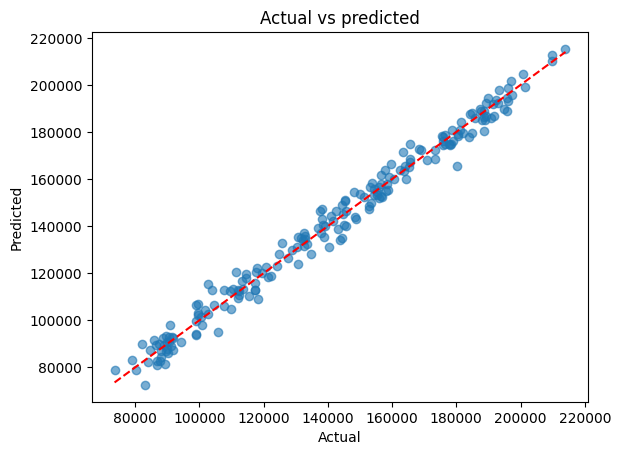

In [41]:
plt.scatter(y_test,y_test_pred,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs predicted")
plt.show()
plt.show()

In [42]:
import joblib
joblib.dump(lr_model,"salary_model.pkl")


['salary_model.pkl']